# 🧠 Réseau Bayésien — Prédiction du Diabète
## Dataset : BRFSS 2015 — Health Indicators

Ce notebook implémente un **réseau bayésien discret** pour prédire si un patient est diabétique à partir de 21 features décrivant ses habitudes de vie et son état de santé.

### Plan
1. Imports & configuration
2. Chargement et exploration des données
3. Prétraitement — Discrétisation
4. Split Train / Test
5. Naïve Bayes — modèle de référence
6. Réseau Bayésien — Structure Hill Climbing
7. Réseau Bayésien — Structure Experte
8. Apprentissage des paramètres (CPTs)
9. Évaluation et comparaison
10. Inférence — Requêtes probabilistes
11. Conclusion


---
## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.naive_bayes import CategoricalNB

# pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE, DiscreteBayesianEstimator
from pgmpy.estimators import HillClimbSearch, BIC
from pgmpy.inference import VariableElimination

import networkx as nx

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

import pgmpy
print(f'pgmpy {pgmpy.__version__} — Tous les imports OK')

pgmpy 1.1.2 — Tous les imports OK


---
## 2. Chargement et Exploration

In [2]:
DATA_PATH = 'data\diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df_raw = pd.read_csv(DATA_PATH)

FEATURE_DESC = {
    'Diabetes_binary':      'Diabetes - target feature (0 = non diabetic, 1 = diabetic)',
    'HighBP':               'High blood pressure (0/1)',
    'HighChol':             'High Cholesterol (0/1)',
    'CholCheck':            '0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years',
    'BMI':                  'Body mass index',
    'Smoker':               'Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes',
    'Stroke':               '(Ever told) you had a stroke. 0 = no 1 = yes',
    'HeartDiseaseorAttack': 'coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes',
    'PhysActivity':         'physical activity in past 30 days - not including job 0 = no 1 = yes',
    'Fruits':               'Consume Fruit 1 or more times per day 0 = no 1 = yes',
    'Veggies':              'Consume Vegetables 1 or more times per day 0 = no 1 = yes)',
    'HvyAlcoholConsump':    'Heavy drinkers 0 = no 1 = yes',
    'AnyHealthcare':        'Do you have any kind of health care coverage, including health insurance, prepaid plans such as HMOs, or government plans such as Medicare, or Indian Health Service - (1/0)',
    'NoDocbcCost':          'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? (0/1)',
    'GenHlth':              'Would you say that in general your health is (1=Excellent → 5=Bad)',
    'MentHlth':             'Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good? (0–30)',
    'PhysHlth':             'Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? (0–30)',
    'DiffWalk':             'Do you have serious difficulty walking or climbing stairs? (0/1)',
    'Sex':                  'Indicate sex of respondent (0=Femme, 1=Homme)',
    'Age':                  'Fourteen-level age category (1=18-24 > 13=80+)',
    'Education':            'What is the highest grade or year of school you completed? (1–6)',
    'Income':               'Is your annual household income from all sources (1–8)',
}

print(f'Shape : {df_raw.shape[0]} obs, {df_raw.shape[1]} variables')
print(f'Valeurs manquantes : {df_raw.isnull().sum().sum()}')

Shape : 70692 obs, 22 variables
Valeurs manquantes : 0


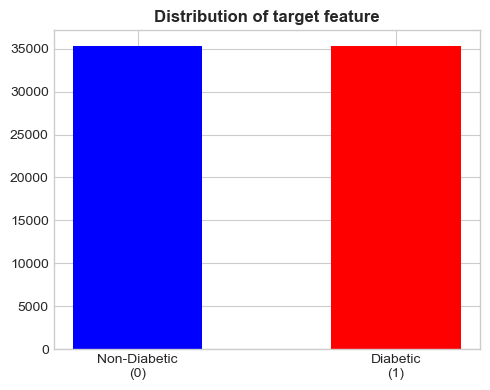

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(5, 4))

# Distribution cible
counts = df_raw['Diabetes_binary'].value_counts().sort_index()
axes.bar(['Non-Diabetic\n(0)', 'Diabetic\n(1)'],
            counts.values, color=['blue','red'], width=0.5)
axes.set_title('Distribution of target feature', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Prétraitement — Discrétisation
To simplify the features we'll discretize 3 of them : BMI, MentHlth and PhysHlth\ 
*   BMI : convert the feature into 5 subclasses based on the World Health Organization.
    *   Underweight : [0 , 18.5] 
    *   Normal weight < 25  
    *   Overweight     < 30  
    *   Obesity I      < 35  
    *   Obesity II     > 35

*   MentHlth and PhysHlth : convert these features into 4 intervalles. 
<p style="text-align:center;">0 = 0 day  |  1 =  1-7 days  |  2 =  8-14 days  |  3 =  15-30 days</p>
    

*   Élément de niveau 1
    *   Élément de niveau 2 (indenté avec une tabulation)
        *   Élément de niveau 3

In [26]:
df = df_raw.copy().astype(int)

# divide the BMI values into 5 sub classes from the OMS
bmi_bins   = [0, 18, 24, 29, 34, 999]
bmi_labels = [0, 1, 2, 3, 4]
df['BMI'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels, right=True).astype(int)
BMI_NAMES = {0:'Underweight', 1:'Normalweight', 2:'Overweight', 3:'Obesity I', 4:'Obesity II-III'}

# divide the MentHlth and PhysHlthinto features into 4 sub classes
def disc_days(x):
    if x == 0:    
        return 0
    elif x <= 7:  
        return 1
    elif x <= 14: 
        return 2
    else:         
        return 3

df['MentHlth'] = df['MentHlth'].apply(disc_days)
df['PhysHlth'] = df['PhysHlth'].apply(disc_days)
DAYS_NAMES = {0:'0 day', 1:'1-7 days', 2:'8-14 days', 3:'15-30 days'}

display(df[['BMI', 'MentHlth', 'PhysHlth']].describe())

,BMI,MentHlth,PhysHlth
count,70692.000000,70692.000000,70692.000000
mean,2.421844,0.584946,0.837676
std,1.052882,1.000466,1.138114
min,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,3.000000,1.000000,1.000000
max,4.000000,3.000000,3.000000


---
## 4. Split Train / Test

In [9]:
TARGET   = 'Diabetes_binary'
FEATURES = [c for c in df.columns if c != TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURES], df[TARGET], test_size=0.2, random_state=SEED, stratify=df[TARGET]
)
df_train = pd.concat([X_train, y_train], axis=1)
df_test  = pd.concat([X_test,  y_test],  axis=1)

print(f'Train : {len(df_train):,} obs.  |  Test : {len(df_test):,} obs.')
print(f'Équilibre train : {dict(y_train.value_counts().sort_index())}')
print(f'Équilibre test  : {dict(y_test.value_counts().sort_index())}')

Train : 56,553 obs.  |  Test : 14,139 obs.
Équilibre train : {0: np.int64(28276), 1: np.int64(28277)}
Équilibre test  : {0: np.int64(7070), 1: np.int64(7069)}


---
## 5. Naïve Bayes — Modèle de Référence

Le Naïve Bayes est un **cas particulier du réseau bayésien** : toutes les features sont supposées indépendantes conditionnellement à la classe. Formellement :

$$P(y \mid x_1, ..., x_n) \propto P(y) \prod_{i=1}^{n} P(x_i \mid y)$$

In [10]:
nb = CategoricalNB()
nb.fit(X_train, y_train)
y_pred_nb  = nb.predict(X_test)
y_proba_nb = nb.predict_proba(X_test)[:, 1]

print('=== Naïve Bayes — Baseline ===')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba_nb):.4f}')
print()
print(classification_report(y_test, y_pred_nb,
      target_names=['Non-Diabétique','Diabétique']))

=== Naïve Bayes — Baseline ===
  Accuracy : 0.7302
  ROC-AUC  : 0.8117

                precision    recall  f1-score   support

Non-Diabétique       0.73      0.74      0.73      7070
    Diabétique       0.73      0.72      0.73      7069

      accuracy                           0.73     14139
     macro avg       0.73      0.73      0.73     14139
  weighted avg       0.73      0.73      0.73     14139



---
## 6. Réseau Bayésien — Structure Hill Climbing

L'algorithme **Hill Climbing** explore l'espace des DAG en ajoutant/supprimant/inversant des arêtes, en maximisant le score **BIC** :

$$\text{BIC} = \log P(D \mid \hat{\theta}, G) - \frac{k}{2} \log n$$

où $k$ est le nombre de paramètres et $n$ le nombre d'observations.

In [11]:
print('Apprentissage de structure (Hill Climbing + BIC)...')
print('Sous-échantillon de 5 000 obs. pour la vitesse\n')

df_sample = df_train.sample(n=min(5000, len(df_train)), random_state=SEED)
hc = HillClimbSearch(df_sample)
hc_dag = hc.estimate(
    scoring_method=BIC(df_sample),
    max_indegree=4,
    max_iter=500,
    epsilon=1e-4,
    show_progress=True
)
hc_edges = list(hc_dag.edges())
print(f'\nStructure apprise : {len(hc_edges)} arêtes')
for e in sorted(hc_edges):
    print(f'  {e[0]} → {e[1]}')

Apprentissage de structure (Hill Climbing + BIC)...
Sous-échantillon de 5 000 obs. pour la vitesse



  8%|▊         | 38/500 [00:02<00:32, 14.35it/s]


Structure apprise : 38 arêtes
  AnyHealthcare → CholCheck
  Diabetes_binary → BMI
  Diabetes_binary → CholCheck
  Diabetes_binary → HighBP
  Diabetes_binary → HighChol
  Diabetes_binary → HvyAlcoholConsump
  DiffWalk → BMI
  DiffWalk → Diabetes_binary
  DiffWalk → PhysActivity
  DiffWalk → PhysHlth
  DiffWalk → Stroke
  Education → Smoker
  Fruits → Veggies
  GenHlth → Diabetes_binary
  GenHlth → DiffWalk
  GenHlth → HeartDiseaseorAttack
  GenHlth → HighBP
  GenHlth → Income
  GenHlth → NoDocbcCost
  GenHlth → PhysActivity
  GenHlth → PhysHlth
  HeartDiseaseorAttack → HighChol
  HeartDiseaseorAttack → Stroke
  HighBP → Age
  HighBP → BMI
  HighBP → HeartDiseaseorAttack
  HighBP → HighChol
  HighChol → Age
  HighChol → Smoker
  Income → Education
  Income → Sex
  NoDocbcCost → AnyHealthcare
  PhysActivity → Fruits
  PhysActivity → Veggies
  PhysHlth → MentHlth
  Sex → Fruits
  Smoker → HvyAlcoholConsump
  Smoker → Sex


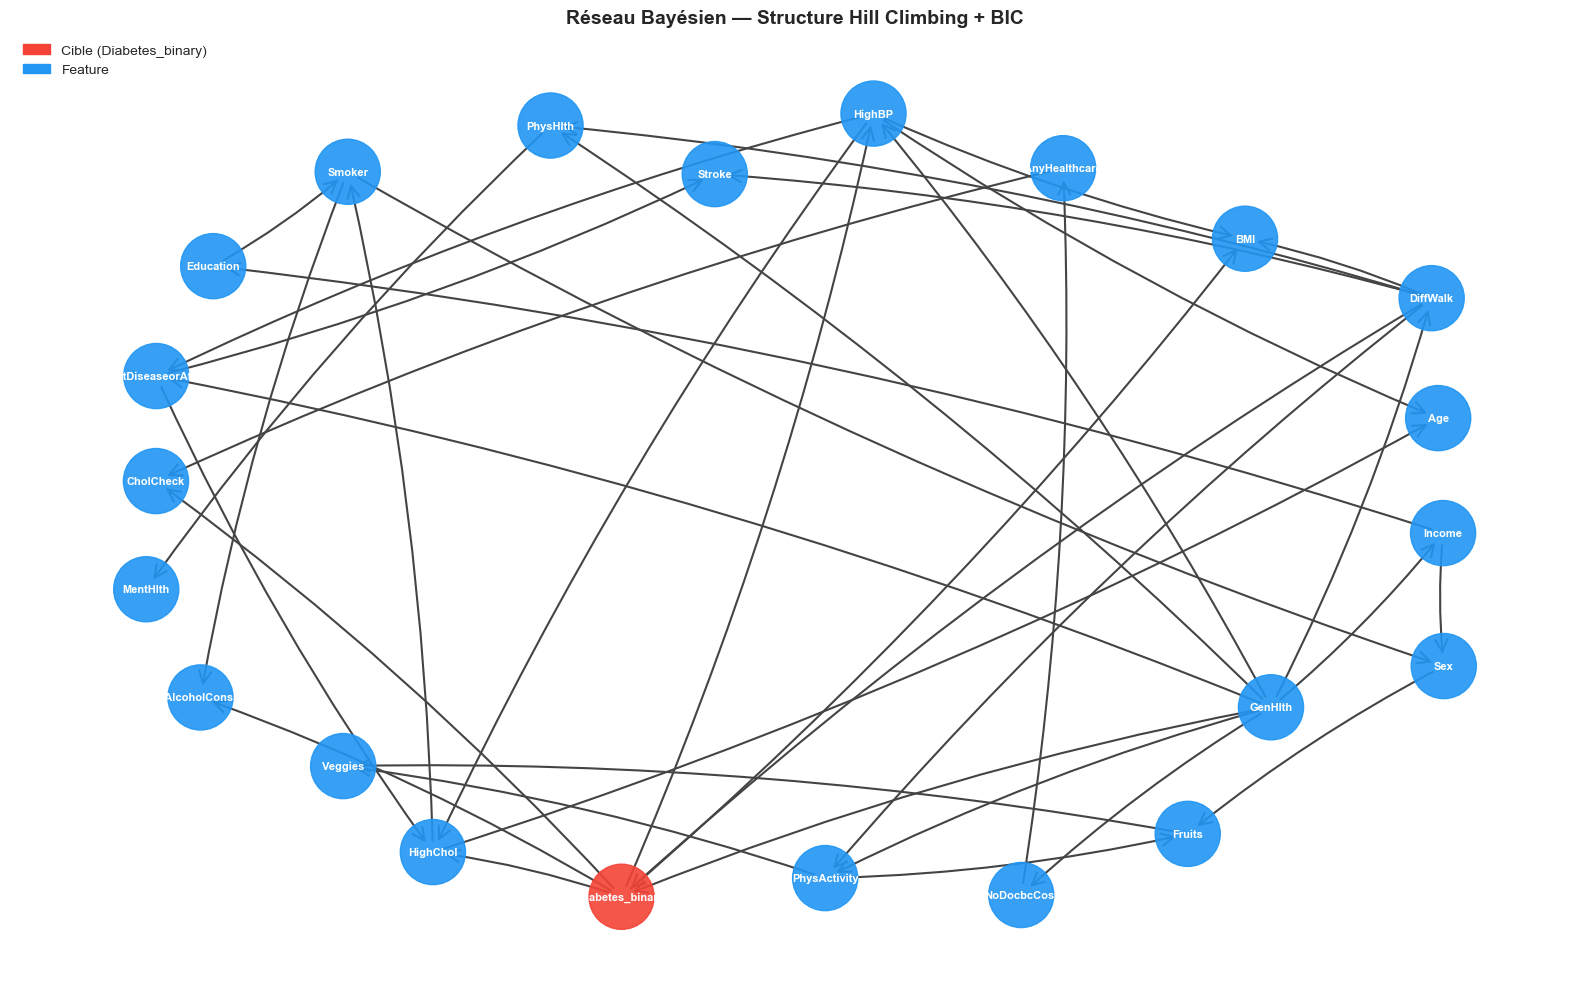

In [12]:
def plot_bn(edges, title, target=TARGET, figsize=(16,10)):
    G = nx.DiGraph(edges)
    colors = ['#F44336' if n==target else '#2196F3' for n in G.nodes()]
    fig, ax = plt.subplots(figsize=figsize)
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except Exception:
        pos = nx.spring_layout(G, seed=SEED, k=3.0)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=2200, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='#444', arrows=True, arrowsize=22,
                           arrowstyle='->', width=1.5, connectionstyle='arc3,rad=0.05', ax=ax)
    ax.legend(handles=[
        mpatches.Patch(color='#F44336', label=f'Cible ({target})'),
        mpatches.Patch(color='#2196F3', label='Feature'),
    ], loc='upper left')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_bn(hc_edges, 'Réseau Bayésien — Structure Hill Climbing + BIC')

---
## 7. Réseau Bayésien — Structure Experte

Structure encodant des relations causales **médicamente plausibles** :
- Déterminants sociaux (âge, revenu, éducation) → accès aux soins & comorbidités
- Style de vie (activité, alimentation, tabac, alcool) → BMI
- BMI → hypertension, cholestérol → diabète
- Santé générale → symptômes fonctionnels (marche, jours mauvaise santé)

Structure experte : 34 arêtes


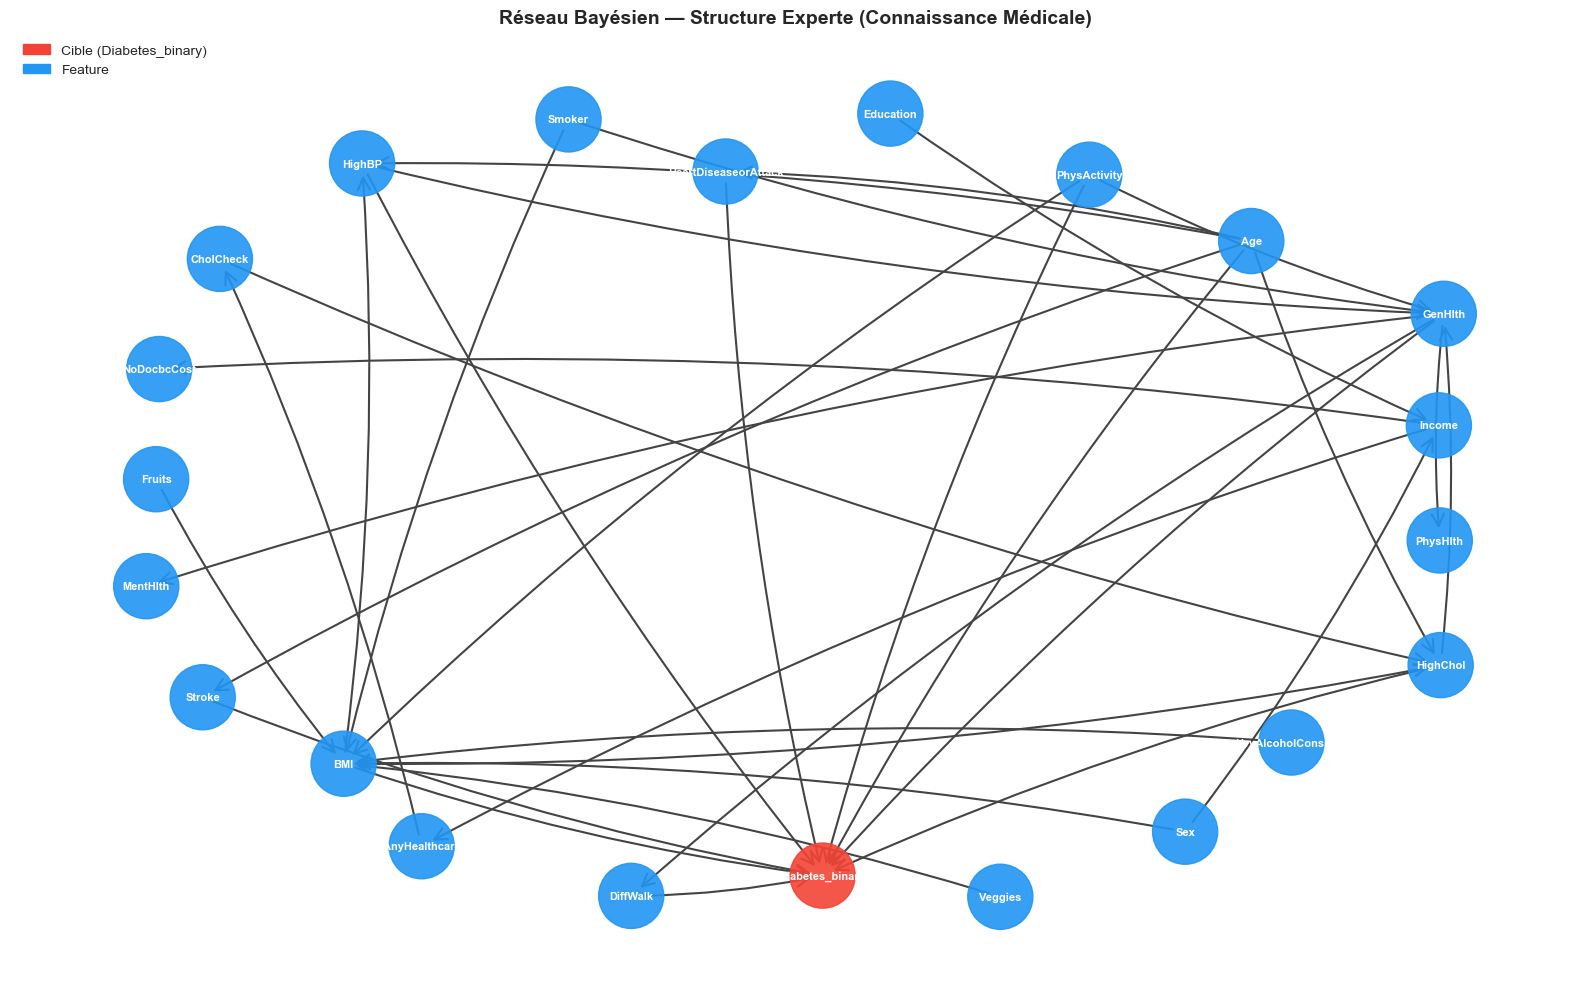

In [29]:
expert_edges = [
    # Déterminants sociaux
    ('Education',            'Income'),
    ('Income',               'AnyHealthcare'),
    ('Income',               'NoDocbcCost'),
    ('Age',                  'HighBP'),
    ('Age',                  'HighChol'),
    ('Age',                  'Stroke'),
    ('Age',                  'HeartDiseaseorAttack'),
    ('Age',                  'Diabetes_binary'),
    ('Sex',                  'Income'),
    ('Sex',                  'BMI'),
    # Style de vie → BMI
    ('PhysActivity',         'BMI'),
    ('Fruits',               'BMI'),
    ('Veggies',              'BMI'),
    ('HvyAlcoholConsump',    'BMI'),
    ('Smoker',               'BMI'),
    # BMI → facteurs cardiovasculaires
    ('BMI',                  'HighBP'),
    ('BMI',                  'HighChol'),
    ('BMI',                  'Diabetes_binary'),
    # Facteurs de risque → Diabète
    ('HighBP',               'Diabetes_binary'),
    ('HighChol',             'Diabetes_binary'),
    ('HeartDiseaseorAttack', 'Diabetes_binary'),
    ('Stroke',               'Diabetes_binary'),
    ('PhysActivity',         'Diabetes_binary'),
    ('GenHlth',              'Diabetes_binary'),
    ('DiffWalk',             'Diabetes_binary'),
    # Santé générale
    ('HighBP',               'GenHlth'),
    ('HighChol',             'GenHlth'),
    ('Smoker',               'GenHlth'),
    ('PhysActivity',         'GenHlth'),
    # GenHlth → symptômes
    ('GenHlth',              'DiffWalk'),
    ('GenHlth',              'PhysHlth'),
    ('GenHlth',              'MentHlth'),
    # Accès soins → dépistage
    ('AnyHealthcare',        'CholCheck'),
    ('CholCheck',            'HighChol'),
]

print(f'Structure experte : {len(expert_edges)} arêtes')
plot_bn(expert_edges, 'Réseau Bayésien — Structure Experte (Connaissance Médicale)')

---
## 8. Apprentissage des Paramètres (CPTs)

Estimation bayésienne avec prior **BDeu** (Bayesian Dirichlet equivalent uniform) :

$$P(X_i = k \mid Pa(X_i) = j) = \frac{N_{ijk} + \alpha / (r_i \cdot q_i)}{N_{ij} + \alpha / q_i}$$

Le prior évite les probabilités nulles pour les combinaisons non observées.

In [30]:
def build_bn(edges, df_train, name='BN'):
    model = DiscreteBayesianNetwork(edges)
    model.fit(
        data=df_train,
        estimator=DiscreteBayesianEstimator(prior_type='BDeu', equivalent_sample_size=5)
    )
    assert model.check_model(), f'{name} invalide !'
    print(f'  {name:<20} : {len(model.nodes())} noeuds | {len(model.edges())} arêtes | OK')
    return model

print('Entraînement des modèles (paramètres) :')
bn_hc     = build_bn(hc_edges,     df_train, 'BN-HillClimbing')
bn_expert = build_bn(expert_edges, df_train, 'BN-Expert')

Entraînement des modèles (paramètres) :
  BN-HillClimbing      : 22 noeuds | 38 arêtes | OK


  2%|▏         | 215/13722 [02:11<2:17:44,  1.63it/s]


  BN-Expert            : 22 noeuds | 34 arêtes | OK


In [31]:
# Inspection de la CPT de Diabetes_binary
cpd = bn_expert.get_cpds('Diabetes_binary')
print(f'CPT de Diabetes_binary | Parents : {cpd.variables[1:]}')
print(cpd)

CPT de Diabetes_binary | Parents : ['Age', 'BMI', 'DiffWalk', 'GenHlth', 'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'PhysActivity', 'Stroke']
+----------------------+-----+-------------------------+
| Age                  | ... | Age(13)                 |
+----------------------+-----+-------------------------+
| BMI                  | ... | BMI(4)                  |
+----------------------+-----+-------------------------+
| DiffWalk             | ... | DiffWalk(1)             |
+----------------------+-----+-------------------------+
| GenHlth              | ... | GenHlth(5)              |
+----------------------+-----+-------------------------+
| HeartDiseaseorAttack | ... | HeartDiseaseorAttack(1) |
+----------------------+-----+-------------------------+
| HighBP               | ... | HighBP(1)               |
+----------------------+-----+-------------------------+
| HighChol             | ... | HighChol(1)             |
+----------------------+-----+-------------------------+


CPT HighBP | Parents : ['Age', 'BMI']


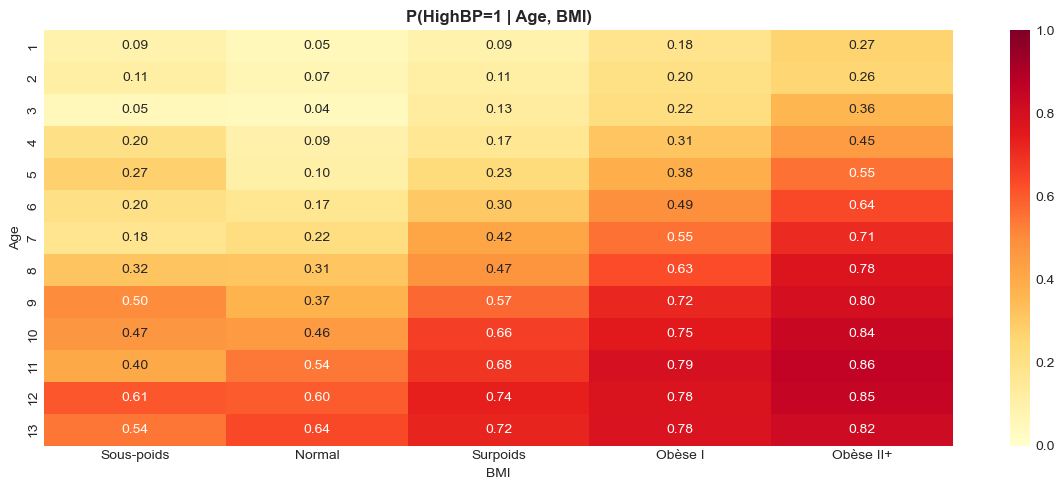

In [32]:
# Visualisation CPT HighBP = f(Age, BMI)
cpd_bp = bn_expert.get_cpds('HighBP')
parents_bp = cpd_bp.variables[1:]
print(f'CPT HighBP | Parents : {parents_bp}')

if set(parents_bp) == {'Age', 'BMI'}:
    n_age = df_train['Age'].nunique()
    n_bmi = df_train['BMI'].nunique()
    ages = sorted(df_train['Age'].unique())
    bmis = sorted(df_train['BMI'].unique())

    p_highbp1 = cpd_bp.values[1]  # P(HighBP=1 | parents)
    if parents_bp[0] == 'Age':
        mat = p_highbp1.reshape(n_age, n_bmi)
        rows, cols = ages, [BMI_NAMES[b] for b in bmis]
        rlbl, clbl = 'Age', 'BMI'
    else:
        mat = p_highbp1.reshape(n_bmi, n_age)
        rows, cols = [BMI_NAMES[b] for b in bmis], ages
        rlbl, clbl = 'BMI', 'Age'

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=cols, yticklabels=rows, ax=ax, vmin=0, vmax=1)
    ax.set_title('P(HighBP=1 | Age, BMI)', fontweight='bold')
    ax.set_xlabel(clbl)
    ax.set_ylabel(rlbl)
    plt.tight_layout()
    plt.show()
else:
    print(cpd_bp)

---
## 9. Évaluation et Comparaison des Modèles

In [ ]:
def predict_bn(model, df_test, target=TARGET):
    X_te   = df_test.drop(columns=[target])
    y_pred = model.predict(X_te)[target].values  #binary classification: a diabetic is predicted if its associated probability is higher to 0.5
    proba  = model.predict_probability(X_te)     #get the probability table
    col    = f'{target}_1'
    y_prob = proba[col].values if col in proba.columns else None
    return y_pred, y_prob

print('Prédictions en cours (peut prendre quelques minutes)...\n')
y_pred_hc,     y_prob_hc     = predict_bn(bn_hc,     df_test)
y_pred_expert, y_prob_expert = predict_bn(bn_expert,  df_test)

RESULTS = {
    'Naïve Bayes':      (y_pred_nb,     y_proba_nb),
    'BN HillClimbing':  (y_pred_hc,     y_prob_hc),
    'BN Expert':        (y_pred_expert, y_prob_expert),
}

print(f'{"Modèle":<20} {"Accuracy":>10} {"ROC-AUC":>10} {"Recall":>10} {"Precision":>11} {"F1":>8}')
print('-'*72)
PERF = {}
for name, (yp, yprob) in RESULTS.items():
    acc  = accuracy_score(y_test, yp)
    auc  = roc_auc_score(y_test, yprob) if yprob is not None else float('nan')
    rep  = classification_report(y_test, yp, output_dict=True)
    rec, prec, f1 = rep['1']['recall'], rep['1']['precision'], rep['1']['f1-score']
    PERF[name] = dict(Accuracy=acc, AUC=auc, Recall=rec, Precision=prec, F1=f1)
    print(f'{name:<20} {acc:>10.4f} {auc:>10.4f} {rec:>10.4f} {prec:>11.4f} {f1:>8.4f}')

Prédictions en cours (peut prendre quelques minutes)...



100%|██████████| 13722/13722 [07:11<00:00, 31.82it/s]


Modèle                 Accuracy    ROC-AUC     Recall   Precision       F1
------------------------------------------------------------------------
Naïve Bayes              0.7302     0.8117     0.7247      0.7328   0.7287
BN HillClimbing          0.4963     0.8084     0.5670      0.4967   0.5295
BN Expert                0.4898     0.7875     0.4607      0.4891   0.4745


We can notice a poor accuracy for the two bayesian network we developped. The naïve bayes model has a much higher accuracy with a difference of 23 and 24 percents. This metric is not quite adapted to assess the quality of the two bayesian network. the prediction argument will return the prediction with the highest probability, in a binary classification it will return the prediction with a probability higher to 0.5. It means here that the model will label as diabetic a patient with only 50% confidence in some cases. Therefore, it is not really signigicant and explain why the two bayesian model have only an accuracy of 49 and 48%.  

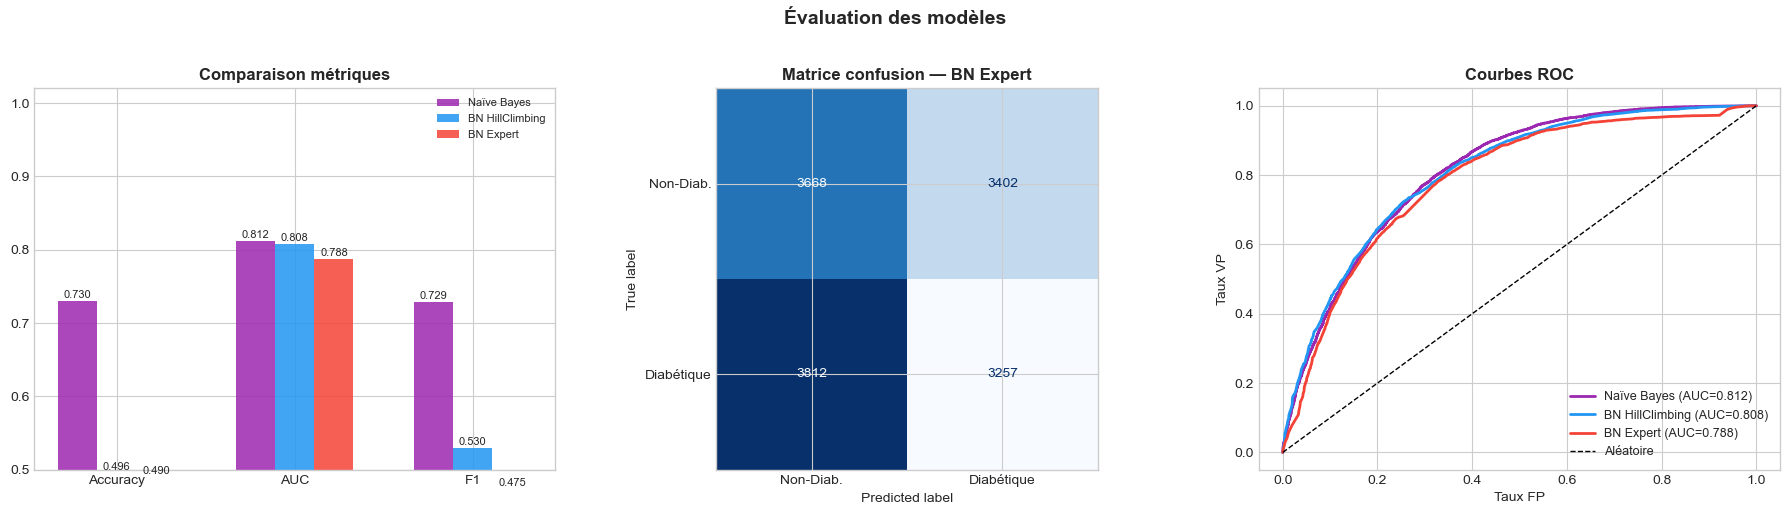

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pal = ['#9C27B0','#2196F3','#F44336']

# Métriques
metrics_show = ['Accuracy','AUC','F1']
x = np.arange(len(metrics_show))
w = 0.22
for i, (name, color) in enumerate(zip(PERF.keys(), pal)):
    vals = [PERF[name][m] for m in metrics_show]
    bars = axes[0].bar(x+i*w, vals, w, label=name, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+.004,
                     f'{v:.3f}', ha='center', fontsize=8)
axes[0].set_xticks(x+w); axes[0].set_xticklabels(metrics_show)
axes[0].set_ylim(0.5, 1.02)
axes[0].set_title('Comparaison métriques', fontweight='bold')
axes[0].legend(fontsize=8)

# Matrice de confusion BN Expert
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_expert),
    display_labels=['Non-Diab.','Diabétique']
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matrice confusion — BN Expert', fontweight='bold')

# ROC
for (name, (yp, yprob)), color in zip(RESULTS.items(), pal):
    if yprob is not None:
        fpr, tpr, _ = roc_curve(y_test, yprob)
        axes[2].plot(fpr, tpr, label=f'{name} (AUC={PERF[name]["AUC"]:.3f})',
                     color=color, lw=2)
axes[2].plot([0,1],[0,1],'k--',lw=1,label='Aléatoire')
axes[2].set(xlabel='Taux FP', ylabel='Taux VP')
axes[2].set_title('Courbes ROC', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Évaluation des modèles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [35]:
best = max(PERF, key=lambda k: PERF[k]['AUC'])
print(f'=== Rapport complet — {best} (meilleur AUC) ===')
print(classification_report(y_test, RESULTS[best][0],
      target_names=['Non-Diabétique','Diabétique']))

=== Rapport complet — Naïve Bayes (meilleur AUC) ===
                precision    recall  f1-score   support

Non-Diabétique       0.73      0.74      0.73      7070
    Diabétique       0.73      0.72      0.73      7069

      accuracy                           0.73     14139
     macro avg       0.73      0.73      0.73     14139
  weighted avg       0.73      0.73      0.73     14139



---
## 10. Inférence — Requêtes Probabilistes

La **Variable Elimination** calcule exactement :
$$P(\text{Diabetes} \mid \text{evidence}) \propto \sum_{h} P(\text{Diabetes}, h, \text{evidence})$$

On peut poser des questions avec des **évidences partielles**, sans avoir toutes les valeurs.

In [38]:
inference = VariableElimination(bn_expert)

def query_(evidence, label=''):
    if label: print(f'--- {label} ---')
    res = inference.query(variables=[TARGET], evidence=evidence, show_progress=False)
    p0, p1 = res.values[0], res.values[1]
    print(f'  P(Non-Diabétique) = {p0*100:.1f}%')
    print(f'  P(Diabétique)     = {p1*100:.1f}%  → {"ÉLEVÉ" if p1>0.5 else "FAIBLE"}\n')
    return p1

print('Moteur d\'inférence (Variable Elimination) initialisé\n')

# Profil à haut risque : 60-64 ans, obèse, hypertendu, sédentaire
p_hr = query_({'Age':9,'BMI':3,'HighBP':1,'HighChol':1,'PhysActivity':0,'GenHlth':4},
             'Profil 1 — Haut risque : 60-64 ans, obèse I, hypertendu, cholestérol élevé, sédentaire')

# Profil faible risque : 25-34 ans, poids normal, actif
p_lr = query_({'Age':3,'BMI':1,'HighBP':0,'HighChol':0,'PhysActivity':1,'GenHlth':1},
             'Profil 2 — Faible risque : 25-34 ans, poids normal, actif, excellente santé')

# Effet seul de l'obésité sévère
p_ob = query_({'BMI':4},
             'Profil 3 — Obésité seule : BMI obèse II+ (≥35), pas d\'autre info')

# AVC + maladies cardiaques
p_card = query_({'Age':7,'Stroke':1,'HeartDiseaseorAttack':1,'HighBP':1,'BMI':2},
               'Profil 4 — Comorbidités : 50-54 ans, AVC, maladie cardiaque, surpoids')

Moteur d'inférence (Variable Elimination) initialisé

--- Profil 1 — Haut risque : 60-64 ans, obèse I, hypertendu, cholestérol élevé, sédentaire ---
  P(Non-Diabétique) = 21.0%
  P(Diabétique)     = 79.0%  → ÉLEVÉ

--- Profil 2 — Faible risque : 25-34 ans, poids normal, actif, excellente santé ---
  P(Non-Diabétique) = 97.0%
  P(Diabétique)     = 3.0%  → FAIBLE

--- Profil 3 — Obésité seule : BMI obèse II+ (≥35), pas d'autre info ---
  P(Non-Diabétique) = 31.9%
  P(Diabétique)     = 68.1%  → ÉLEVÉ

--- Profil 4 — Comorbidités : 50-54 ans, AVC, maladie cardiaque, surpoids ---
  P(Non-Diabétique) = 44.1%
  P(Diabétique)     = 55.9%  → ÉLEVÉ



=== Analyse de sensibilité ===
Facteur                             Présent     Absent        Δ
--------------------------------------------------------------
  Hypertension artérielle             0.647      0.318   +0.329
  Cholestérol élevé                   0.613      0.380   +0.233
  Tabagisme                           0.514      0.490   +0.025
  Antécédent AVC                      0.599      0.495   +0.104
  Maladie cardiaque                   0.642      0.477   +0.165
  Activité physique                   0.470      0.577   -0.107
  Difficulté à marcher                0.649      0.452   +0.197
  Alcool excessif                     0.469      0.503   -0.034


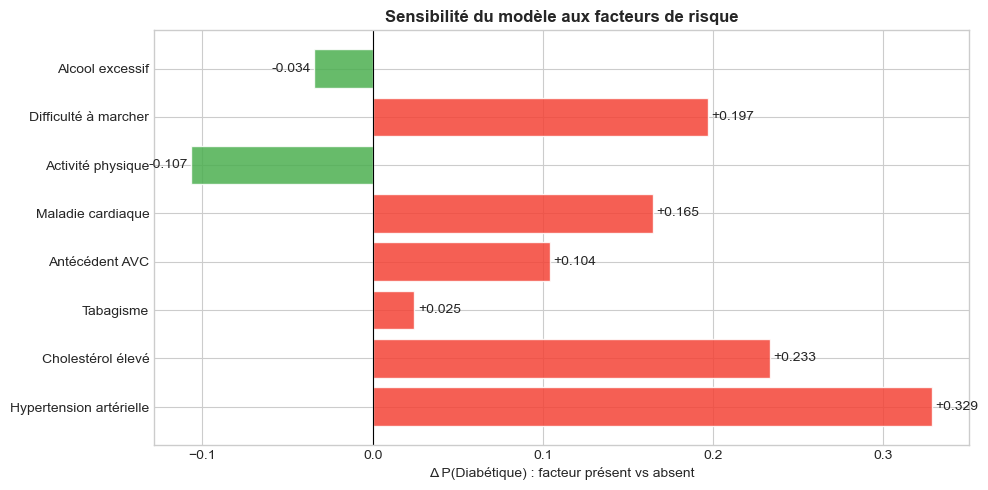

In [39]:
# Analyse de sensibilité : impact de chaque facteur binaire
binary_factors = [
    ('HighBP',               'Hypertension artérielle'),
    ('HighChol',             'Cholestérol élevé'),
    ('Smoker',               'Tabagisme'),
    ('Stroke',               'Antécédent AVC'),
    ('HeartDiseaseorAttack', 'Maladie cardiaque'),
    ('PhysActivity',         'Activité physique'),
    ('DiffWalk',             'Difficulté à marcher'),
    ('HvyAlcoholConsump',    'Alcool excessif'),
]

sensitivity = []
print('=== Analyse de sensibilité ===')
print(f'{"Facteur":<32} {"Présent":>10} {"Absent":>10} {"Δ":>8}')
print('-'*62)
for col, label in binary_factors:
    if col in bn_expert.nodes():
        r1 = inference.query(variables=[TARGET], evidence={col:1}, show_progress=False)
        r0 = inference.query(variables=[TARGET], evidence={col:0}, show_progress=False)
        p1y, p1n = r1.values[1], r0.values[1]
        diff = p1y - p1n
        sensitivity.append((label, p1y, p1n, diff))
        print(f'  {label:<30} {p1y:>10.3f} {p1n:>10.3f} {diff:>+8.3f}')

# Visualisation
fig, ax = plt.subplots(figsize=(10,5))
labels_s = [s[0] for s in sensitivity]
diffs    = [s[3] for s in sensitivity]
bar_cols = ['#F44336' if d>0 else '#4CAF50' for d in diffs]
bars = ax.barh(labels_s, diffs, color=bar_cols, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
for bar, d in zip(bars, diffs):
    x_pos = d+0.002 if d>=0 else d-0.002
    ax.text(x_pos, bar.get_y()+bar.get_height()/2, f'{d:+.3f}',
            va='center', ha='left' if d>=0 else 'right', fontsize=10)
ax.set_xlabel('Δ P(Diabétique) : facteur présent vs absent')
ax.set_title('Sensibilité du modèle aux facteurs de risque', fontweight='bold')
plt.tight_layout()
plt.show()

=== Gradient de risque selon le BMI ===
  0 — Sous-poids   → P(Diabète) = 34.0%
  1 — Normal       → P(Diabète) = 31.6%
  2 — Surpoids     → P(Diabète) = 45.9%
  3 — Obèse I      → P(Diabète) = 57.2%
  4 — Obèse II+    → P(Diabète) = 68.1%


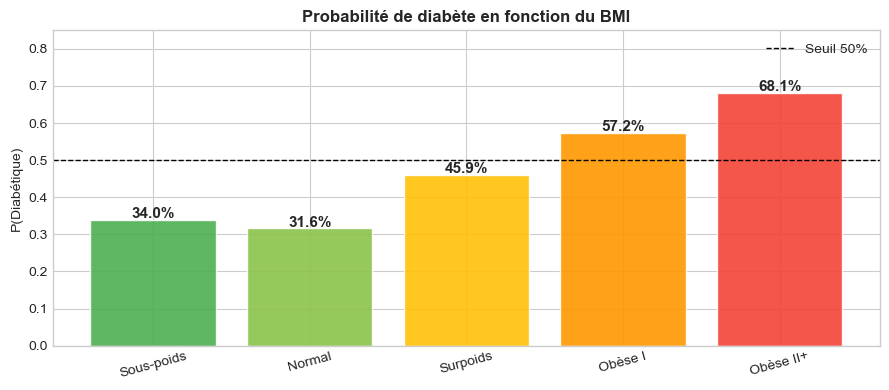

In [40]:
# Gradient risque × BMI
print('=== Gradient de risque selon le BMI ===')
bmi_probs = []
for cat in range(5):
    r = inference.query(variables=[TARGET], evidence={'BMI':cat}, show_progress=False)
    p1 = r.values[1]
    bmi_probs.append(p1)
    print(f'  {cat} — {BMI_NAMES[cat]:<12} → P(Diabète) = {p1*100:.1f}%')

fig, ax = plt.subplots(figsize=(9,4))
bars = ax.bar([BMI_NAMES[i] for i in range(5)], bmi_probs,
               color=['#4CAF50','#8BC34A','#FFC107','#FF9800','#F44336'],
               edgecolor='white', alpha=0.9)
ax.axhline(0.5, color='black', lw=1, linestyle='--', label='Seuil 50%')
for bar, v in zip(bars, bmi_probs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.set_title('Probabilité de diabète en fonction du BMI', fontweight='bold')
ax.set_ylabel('P(Diabétique)')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

=== Gradient de risque selon la tranche d'âge ===


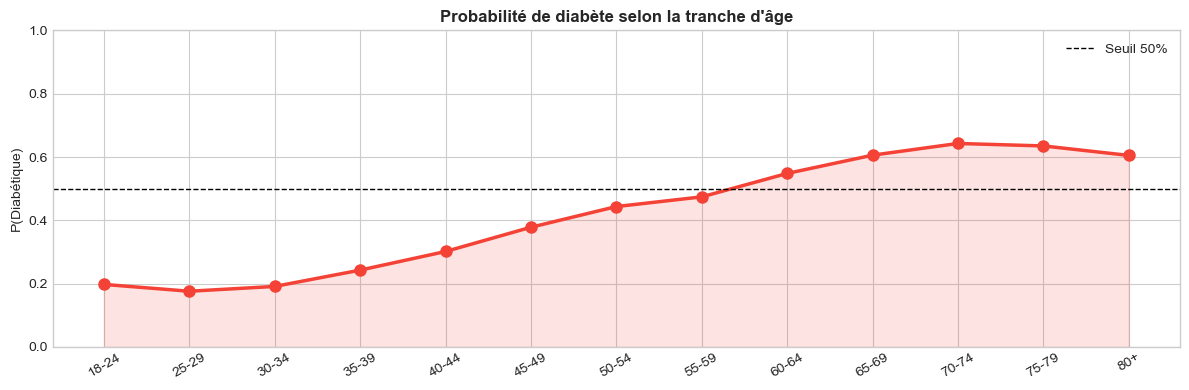

In [41]:
# Gradient risque × Âge
print('=== Gradient de risque selon la tranche d\'âge ===')
AGE_LABELS = {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
              6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
              11:'70-74',12:'75-79',13:'80+'}
age_probs = []
for cat in range(1,14):
    r = inference.query(variables=[TARGET], evidence={'Age':cat}, show_progress=False)
    age_probs.append(r.values[1])

fig, ax = plt.subplots(figsize=(12,4))
x_ages = list(range(1,14))
ax.plot(x_ages, age_probs, marker='o', color='#F44336', lw=2.5, ms=8)
ax.fill_between(x_ages, age_probs, alpha=0.15, color='#F44336')
ax.axhline(0.5, color='black', lw=1, linestyle='--', label='Seuil 50%')
ax.set_xticks(x_ages)
ax.set_xticklabels([AGE_LABELS[a] for a in x_ages], rotation=30)
ax.set_title('Probabilité de diabète selon la tranche d\'âge', fontweight='bold')
ax.set_ylabel('P(Diabétique)')
ax.set_ylim(0,1)
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. Conclusion

### Récapitulatif

| Modèle | Avantages | Limites |
|---|---|---|
| **Naïve Bayes** | Rapide, baseline solide | Indépendance conditionnelle irréaliste |
| **BN Hill Climbing** | Structure données-driven | Optimum local, sensible sous-échantillonnage |
| **BN Expert** | Causal, interprétable, inférence riche | Requiert expertise médicale |

### Principaux facteurs de risque identifiés
1. Hypertension artérielle (HighBP)
2. BMI élevé (obésité)
3. Maladies cardiaques et AVC (comorbidités)
4. Cholestérol élevé
5. Sédentarité (absence d'activité physique)

### Avantages uniques des Réseaux Bayésiens
- **Inférence avec données partielles** : prédit même sans toutes les features
- **Incertitude quantifiée** : distributions de probabilités, pas juste une classe
- **Interprétabilité** : CPTs lisibles par des médecins
- **Raisonnement causal** : simuler des interventions (do-calculus)

### Pistes d'amélioration
- Algorithme **MMHC** (Markov Blanket Hill Climbing) — combine contraintes et score
- Algorithme **PC** (constraint-based) pour valider les indépendances conditionnelles
- Entraînement Hill Climbing sur l'ensemble complet (pas seulement 5 000 obs.)
- **Do-calculus** pour des recommandations préventives chiffrées

In [42]:
print('='*60)
print('  TABLEAU DE BORD FINAL')
print('='*60)
print(f'  Dataset   : {len(df):,} patients | {len(FEATURES)} features')
print(f'  Train/Test: {len(df_train):,} / {len(df_test):,}')
print()
print(f'  {"Modèle":<20} {"Accuracy":>10} {"ROC-AUC":>10} {"F1":>8}')
print(f'  {"-"*50}')
for name, m in PERF.items():
    star = '  ← meilleur AUC' if name==best else ''
    print(f'  {name:<20} {m["Accuracy"]:>10.4f} {m["AUC"]:>10.4f} {m["F1"]:>8.4f}{star}')
print('='*60)

  TABLEAU DE BORD FINAL
  Dataset   : 70,692 patients | 21 features
  Train/Test: 56,553 / 14,139

  Modèle                 Accuracy    ROC-AUC       F1
  --------------------------------------------------
  Naïve Bayes              0.7302     0.8117   0.7287  ← meilleur AUC
  BN HillClimbing          0.4963     0.8084   0.5295
  BN Expert                0.4898     0.7875   0.4745
